# Arabic Vocabulary Reduction Analysis

This notebook analyzes Arabic tokens in model tokenizers and compares the size of dotted vs undotted (Rasm) token vocabularies to measure the potential vocabulary reduction from using undotted Arabic text.

In [1]:
from transformers import AutoTokenizer
from tnqeet import remove_dots
from tnqeet.constants import ARABIC_LETTERS

In [2]:
def contains_arabic(text: str) -> bool:
    """Check if a string contains any Arabic letters."""
    return any(char in ARABIC_LETTERS for char in text)


def analyze_tokenizer_arabic_vocab(model_path: str) -> dict:
    """
    Analyze a tokenizer's vocabulary for Arabic tokens.
    
    Returns a dict with:
    - model_path: the model path
    - total_vocab_size: total vocabulary size
    - arabic_tokens_count: number of tokens containing Arabic letters
    - dotless_tokens_count: number of unique tokens after undotting
    - reduction_ratio: percentage reduction from dotted to dotless
    """
    print(f"Loading tokenizer from: {model_path}")
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    
    vocab = tokenizer.get_vocab()
    print(f"Total vocabulary size: {len(vocab)}")
    
    # Collect tokens containing Arabic letters (list since tokenizer has unique tokens)
    arabic_tokens = set()
    for token in vocab.keys():
        # Decode the token to get the actual text
        decoded_token = tokenizer.convert_tokens_to_string([token]).strip()
        if contains_arabic(decoded_token):
            arabic_tokens.add(decoded_token)
    
    print(f"Arabic tokens set size: {len(arabic_tokens)}")
    
    # Undot the Arabic tokens and add to a set
    dotless_tokens = set()
    for token in arabic_tokens:
        dotless_token = remove_dots(token)
        dotless_tokens.add(dotless_token)
    
    print(f"Dotless tokens set size: {len(dotless_tokens)}")
    
    # Calculate reduction ratio
    if len(arabic_tokens) > 0:
        reduction_ratio = (len(arabic_tokens) - len(dotless_tokens)) / len(arabic_tokens) * 100
    else:
        reduction_ratio = 0.0
    
    print(f"Reduction ratio: {reduction_ratio:.2f}%")
    print("-" * 50)
    
    return {
        "model_path": model_path,
        "total_vocab_size": len(vocab),
        "arabic_tokens_count": len(arabic_tokens),
        "dotless_tokens_count": len(dotless_tokens),
        "reduction_ratio": reduction_ratio,
    }

In [3]:
# List of models to analyze
models = [
    "google/gemma-3-1b-it",
    'openai/gpt-oss-120b',
    "Qwen/Qwen2.5-3B-Instruct",
    "meta-llama/Llama-3.2-1B-Instruct",
    'aubmindlab/bert-base-arabert',
    'humain-ai/ALLaM-7B-Instruct-preview',
    'FreedomIntelligence/AceGPT-v2-8B-Chat',
    'inceptionai/Jais-2-8B-Chat',
    'CAMeL-Lab/bert-base-arabic-camelbert-msa',
    'UBC-NLP/MARBERT',
    'UBC-NLP/AraT5-base',
    'lanwuwei/GigaBERT-v3-Arabic-and-English',
    'QCRI/Fanar-1-9B-Instruct',
    'CohereLabs/c4ai-command-a-03-2025',
    'microsoft/Phi-4-mini-instruct',
    # 'Navid-AI/Yehia-7B-preview',
    
]

In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
# Analyze all models
results = []
for model_path in models:
    result = analyze_tokenizer_arabic_vocab(model_path)
    results.append(result)

Loading tokenizer from: google/gemma-3-1b-it
Total vocabulary size: 262145
Arabic tokens set size: 6938
Dotless tokens set size: 5925
Reduction ratio: 14.60%
--------------------------------------------------
Loading tokenizer from: openai/gpt-oss-120b
Total vocabulary size: 200019
Arabic tokens set size: 6835
Dotless tokens set size: 5820
Reduction ratio: 14.85%
--------------------------------------------------
Loading tokenizer from: Qwen/Qwen2.5-3B-Instruct
Total vocabulary size: 151665
Arabic tokens set size: 3272
Dotless tokens set size: 2806
Reduction ratio: 14.24%
--------------------------------------------------
Loading tokenizer from: meta-llama/Llama-3.2-1B-Instruct
Total vocabulary size: 128256
Arabic tokens set size: 3135
Dotless tokens set size: 2650
Reduction ratio: 15.47%
--------------------------------------------------
Loading tokenizer from: aubmindlab/bert-base-arabert
Total vocabulary size: 64000
Arabic tokens set size: 52057
Dotless tokens set size: 41092
Reduct

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Total vocabulary size: 110000
Arabic tokens set size: 58824
Dotless tokens set size: 48009
Reduction ratio: 18.39%
--------------------------------------------------
Loading tokenizer from: lanwuwei/GigaBERT-v3-Arabic-and-English
Total vocabulary size: 50000
Arabic tokens set size: 26168
Dotless tokens set size: 23217
Reduction ratio: 11.28%
--------------------------------------------------
Loading tokenizer from: QCRI/Fanar-1-9B-Instruct
Total vocabulary size: 128256
Arabic tokens set size: 3788
Dotless tokens set size: 3095
Reduction ratio: 18.29%
--------------------------------------------------
Loading tokenizer from: CohereLabs/c4ai-command-a-03-2025
Total vocabulary size: 255033
Arabic tokens set size: 5610
Dotless tokens set size: 4856
Reduction ratio: 13.44%
--------------------------------------------------
Loading tokenizer from: microsoft/Phi-4-mini-instruct
Total vocabulary size: 200029
Arabic tokens set size: 6835
Dotless tokens set size: 5820
Reduction ratio: 14.85%
---

In [6]:
# Summary table
print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)
print(f"{'Model':<50} {'Total':<10} {'Arabic':<10} {'Arabic%':<10} {'Dotless':<10} {'Reduction':<10}")
print("-" * 100)
for r in sorted(results, key=lambda x: x['reduction_ratio'], reverse=True):
    model_name = r['model_path'].split('/')[-1]
    arabic_pct = r['arabic_tokens_count'] / r['total_vocab_size'] * 100 if r['total_vocab_size'] else 0.0
    print(f"{model_name:<50} {r['total_vocab_size']:<10} {r['arabic_tokens_count']:<10} {arabic_pct:<10.2f} {r['dotless_tokens_count']:<10} {r['reduction_ratio']:.2f}%")


SUMMARY
Model                                              Total      Arabic     Arabic%    Dotless    Reduction 
----------------------------------------------------------------------------------------------------
bert-base-arabert                                  64000      52057      81.34      41092      21.06%
bert-base-arabic-camelbert-msa                     30000      26798      89.33      21542      19.61%
ALLaM-7B-Instruct-preview                          64000      34098      53.28      27435      19.54%
AraT5-base                                         110000     58824      53.48      48009      18.39%
Fanar-1-9B-Instruct                                128256     3788       2.95       3095       18.29%
MARBERT                                            100000     90877      90.88      76048      16.32%
Jais-2-8B-Chat                                     150222     43128      28.71      36186      16.10%
Llama-3.2-1B-Instruct                              128256     3135    

In [7]:
sum(r['reduction_ratio'] for r in results) / len(results)

16.23418474893902

Saved: /raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet/tnqeet/notebooks/figures/arabic_vocab_reduction_by_undotting.pdf


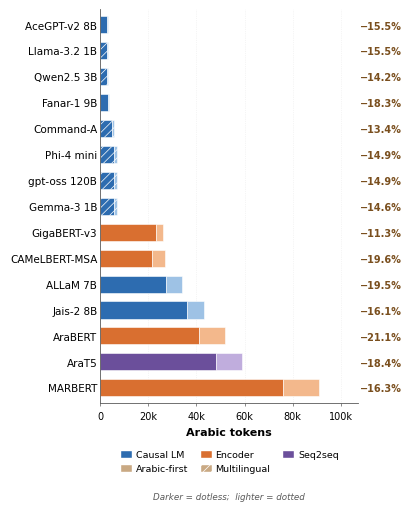

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import Patch


SHORT_NAMES = {
    "google/gemma-3-1b-it": "Gemma-3 1B",
    "openai/gpt-oss-120b": "gpt-oss 120B",
    "Qwen/Qwen2.5-3B-Instruct": "Qwen2.5 3B",
    "meta-llama/Llama-3.2-1B-Instruct": "Llama-3.2 1B",
    "aubmindlab/bert-base-arabert": "AraBERT",
    "humain-ai/ALLaM-7B-Instruct-preview": "ALLaM 7B",
    "FreedomIntelligence/AceGPT-v2-8B-Chat": "AceGPT-v2 8B",
    "inceptionai/Jais-2-8B-Chat": "Jais-2 8B",
    "CAMeL-Lab/bert-base-arabic-camelbert-msa": "CAMeLBERT-MSA",
    "UBC-NLP/MARBERT": "MARBERT",
    "UBC-NLP/AraT5-base": "AraT5",
    "lanwuwei/GigaBERT-v3-Arabic-and-English": "GigaBERT-v3",
    "QCRI/Fanar-1-9B-Instruct": "Fanar-1 9B",
    "CohereLabs/c4ai-command-a-03-2025": "Command-A",
    "microsoft/Phi-4-mini-instruct": "Phi-4 mini",
}

# Arabic-first (purpose-built or Arabic-first) vs multilingual tokenizers.
ARABIC_FIRST = {
    "aubmindlab/bert-base-arabert",
    "humain-ai/ALLaM-7B-Instruct-preview",
    "FreedomIntelligence/AceGPT-v2-8B-Chat",
    "inceptionai/Jais-2-8B-Chat",
    "CAMeL-Lab/bert-base-arabic-camelbert-msa",
    "UBC-NLP/MARBERT",
    "UBC-NLP/AraT5-base",
    "lanwuwei/GigaBERT-v3-Arabic-and-English",
    "QCRI/Fanar-1-9B-Instruct",
}

# Model architecture: causal LM (decoder-only), encoder (MLM), seq2seq.
ARCHITECTURE = {
    "google/gemma-3-1b-it": "causal",
    "openai/gpt-oss-120b": "causal",
    "Qwen/Qwen2.5-3B-Instruct": "causal",
    "meta-llama/Llama-3.2-1B-Instruct": "causal",
    "humain-ai/ALLaM-7B-Instruct-preview": "causal",
    "FreedomIntelligence/AceGPT-v2-8B-Chat": "causal",
    "inceptionai/Jais-2-8B-Chat": "causal",
    "QCRI/Fanar-1-9B-Instruct": "causal",
    "CohereLabs/c4ai-command-a-03-2025": "causal",
    "microsoft/Phi-4-mini-instruct": "causal",
    "aubmindlab/bert-base-arabert": "encoder",
    "CAMeL-Lab/bert-base-arabic-camelbert-msa": "encoder",
    "UBC-NLP/MARBERT": "encoder",
    "lanwuwei/GigaBERT-v3-Arabic-and-English": "encoder",
    "UBC-NLP/AraT5-base": "seq2seq",
}

# Vivid hue per architecture; dark = dotless (kept), light = dotted-only (collapsed).
ARCH_COLORS = {
    "causal":  ("#2d6cb0", "#9ec2e5"),  # blue
    "encoder": ("#d96f30", "#f3b88c"),  # orange
    "seq2seq": ("#6b4f9b", "#c0addd"),  # purple
}
# Warm sand tone used for the family swatches in the legend.
FAMILY_SWATCH = "#c9a983"


def plot_arabic_vocab(
    model_results=results,
    filename='tnqeet/notebooks/figures/arabic_vocab_reduction_by_undotting.pdf',
    figsize=(4.0, 5.0),
):
    """Stacked horizontal bar per tokenizer with three visual cues.

    Each bar = the model's Arabic-token vocab, split into:
      • darker shade → Dotless Arabic (unique rasm forms kept)
      • lighter shade → Dotted-only Arabic (collapsed by undotting)
    Bar color encodes architecture (blue = causal LM, orange = encoder,
    purple = seq2seq). Bar fill style encodes tokenizer family
    (solid = Arabic-First, hatched = multilingual).
    Sorted by Arabic-token count: smallest at top, largest at bottom.
    """
    rc = {
        'mathtext.fontset': 'stix',
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'axes.linewidth': 0.6,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7.5,
        'legend.fontsize': 6.8,
        'hatch.linewidth': 0.5,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    }
    with mpl.rc_context(rc):
        items = sorted(model_results,
                       key=lambda r: r['arabic_tokens_count'], reverse=True)
        n = len(items)
        names = [SHORT_NAMES.get(r['model_path'],
                                 r['model_path'].split('/')[-1])
                 for r in items]
        arch = [ARCHITECTURE.get(r['model_path'], 'causal') for r in items]
        is_arabic = [r['model_path'] in ARABIC_FIRST for r in items]
        arabics = np.array([r['arabic_tokens_count'] for r in items],
                           dtype=float)
        dotless = np.array([r['dotless_tokens_count'] for r in items],
                           dtype=float)
        reductions = np.array([r['reduction_ratio'] for r in items])

        seg_dotless = dotless
        seg_redundant = arabics - dotless

        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        y = np.arange(n)
        bar_h = 0.66

        for yi, ara_flag, sd, sr, ar in zip(
            y, is_arabic, seg_dotless, seg_redundant, arch
        ):
            c_dark, c_light = ARCH_COLORS[ar]
            hatch = '' if ara_flag else '////'
            ax.barh(yi, sd, height=bar_h, color=c_dark,
                    edgecolor='white', linewidth=0.4,
                    hatch=hatch, zorder=2)
            ax.barh(yi, sr, height=bar_h, left=sd, color=c_light,
                    edgecolor='white', linewidth=0.4,
                    hatch=hatch, zorder=2)

        ax.set_yticks(y)
        ax.set_yticklabels(names)
        ax.set_ylim(-0.6, n - 0.4)
        ax.set_xlim(0, float(arabics.max()) * 1.18)
        ax.xaxis.set_major_formatter(
            mpl.ticker.FuncFormatter(
                lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{int(x)}'
            )
        )
        ax.set_xlabel('Arabic tokens', fontweight='bold', labelpad=4)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_color('#5a5a5a')
        ax.spines['bottom'].set_color('#5a5a5a')
        ax.tick_params(axis='both', length=2.5, width=0.5, color='#5a5a5a')
        ax.tick_params(axis='y', length=0, pad=2)
        ax.grid(True, axis='x', alpha=0.25, linestyle=':', linewidth=0.5)
        ax.set_axisbelow(True)

        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks(y)
        ax2.set_yticklabels([f'−{r:.1f}%' for r in reductions],
                            fontsize=7, color="#7a4f1e", fontweight='bold')
        for side in ('top', 'right', 'bottom', 'left'):
            ax2.spines[side].set_visible(False)
        ax2.tick_params(axis='y', length=0, pad=1)

        # Single legend, exactly two rows.
        # matplotlib fills columns top-to-bottom, so the handles are interleaved
        # to render:
        #   Row 1: Causal LM | Encoder | Seq2seq
        #   Row 2: Arabic-first | Multilingual
        legend_handles = [
            Patch(facecolor=ARCH_COLORS['causal'][0], edgecolor='white',
                  label='Causal LM'),
            Patch(facecolor=FAMILY_SWATCH, edgecolor='white',
                  label='Arabic-first'),
            Patch(facecolor=ARCH_COLORS['encoder'][0], edgecolor='white',
                  label='Encoder'),
            Patch(facecolor=FAMILY_SWATCH, edgecolor='white',
                  hatch='////', label='Multilingual'),
            Patch(facecolor=ARCH_COLORS['seq2seq'][0], edgecolor='white',
                  label='Seq2seq'),
        ]
        ax.legend(
            handles=legend_handles,
            loc='upper center', frameon=False, ncol=3,
            bbox_to_anchor=(0.5, -0.11),
            handlelength=1.3, handleheight=0.9,
            handletextpad=0.4, columnspacing=1.2,
            borderaxespad=0.0,
        )

        # Caption explaining the shade encoding, just below the legend.
        ax.text(0.5, -0.225,
                'Darker = dotless;  lighter = dotted',
                ha='center', va='top',
                fontsize=6.3, style='italic', color='#5a5a5a',
                transform=ax.transAxes)

        out_path = Path(filename).expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, bbox_inches='tight', format='pdf')
        print(f"Saved: {out_path}")
        return fig


plot_arabic_vocab()